# Group Project

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


___ 
## 1. Business Understanding

___ 
## 2. Data Understanding

In [62]:
project_df = pd.read_csv("project-dataset/liikenneonnettomuudet_Helsingissa.csv", sep=";")
# project_df.rename(columns={'LAJI': 'TYPE', 'pohj_etrs': "N", 'ita_etrs': "E",'VAKAV_A': "Severity", 'VV': "Year"}, inplace=True) 
print("Datasetin rivien määrä:", len(project_df))
project_df.head()

Datasetin rivien määrä: 53800


,LAJI,pohj_etrs,ita_etrs,VAKAV_A,VV
0,JK,6675786.73,25501661.91,1,2022
1,JK,6674533.32,25502790.94,2,2022
2,JK,6679536.47,25506837.81,2,2022
3,JK,6675297.68,25498807.13,2,2022
4,JK,6674924.21,25495525.13,2,2022


In [63]:
project_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53800 entries, 0 to 53799
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LAJI       53800 non-null  object 
 1   pohj_etrs  53797 non-null  float64
 2   ita_etrs   53797 non-null  float64
 3   VAKAV_A    53800 non-null  int64  
 4   VV         53800 non-null  int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ MB


### Muuttujat
| Muuttuja  | Selitys             | Lisätiedot|
| --------- | ------------------- |---------|
| vakav_a   | vakavuus            |1 = omaisuusvahinko,  2 = loukkaantumiseen johtanut, 3 = kuolemaan johtanut|
| POHJ_ETRS | pohjoiskoordinaatti |Pohjoiskoordinaatti ETRS-GK25-järjestelmässä|
| ITA_ETRS  | itäkoordinaatti     |Itäkoordinaatti ETRS-GK25-järjestelmässä|
| vv        | vuosi               | Vuosi jolloin onnettomuus tapahtunut|
| laji      | onnettomuustyyppi   |jk = jalankulkijaonnettomuus, pp = polkupyöräonnettomuus, mp = mopo/moottoripyöräonnettomuus, ma = moottoriajoneuvo-onnettomuus|


Tarkistetaan puuttuvien arvojen määrä:

In [64]:
project_df.isnull().sum()

LAJI         0
pohj_etrs    3
ita_etrs     3
VAKAV_A      0
VV           0
dtype: int64

___ 
## 3. Data Preparation


Pudotetaan kolme puutteellista riviä.

In [65]:
project_df = project_df.dropna()
project_df.isnull().sum()

LAJI         0
pohj_etrs    0
ita_etrs     0
VAKAV_A      0
VV           0
dtype: int64

Muutetaan kategorinen muuttuja ``laji`` numeeriseksi. 

In [66]:
project_df = pd.get_dummies(project_df, columns=["LAJI"])

In [67]:
project_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53797 entries, 0 to 53799
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pohj_etrs  53797 non-null  float64
 1   ita_etrs   53797 non-null  float64
 2   VAKAV_A    53797 non-null  int64  
 3   VV         53797 non-null  int64  
 4   LAJI_JK    53797 non-null  bool   
 5   LAJI_MA    53797 non-null  bool   
 6   LAJI_MP    53797 non-null  bool   
 7   LAJI_PP    53797 non-null  bool   
dtypes: bool(4), float64(2), int64(2)
memory usage: 2.3 MB


Featuret ja target

In [68]:
X = project_df.drop("VAKAV_A", axis=1)
y = project_df["VAKAV_A"]

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

___ 
## 4. Modeling

### 4.1 Logistic Regression

In [70]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))

Accuracy: 0.7936802973977695


### 4.2 Decision Tree

In [71]:
tree_model = DecisionTreeClassifier(
    max_depth=10,
    ccp_alpha=0.01,
    random_state=123
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_tree))

Accuracy: 0.8427509293680298


### 4.3 Random Forest

In [72]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=123
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.820817843866171


___ 
## 5. Evaluation


### 5.1 Evaluation of Logistic Regression

Logistic Regression Confusion Matrix:
 [[8540    0    0]
 [2177    0    0]
 [  43    0    0]]


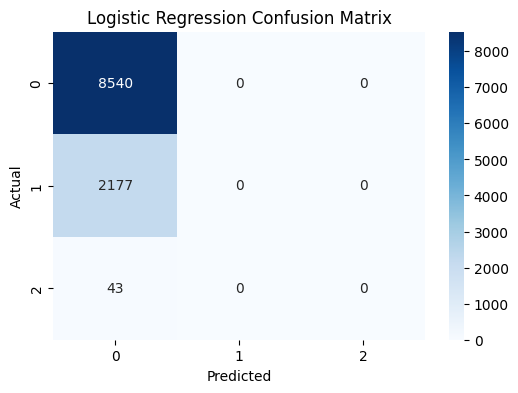

In [73]:
# Ennusteet
y_pred_log = log_model.predict(X_test)

# Confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)
print("Logistic Regression Confusion Matrix:\n", cm_log)

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 5.2 Evaluation of Decision Tree

Decision Tree Confusion Matrix:
 [[7932  608    0]
 [1041 1136    0]
 [  12   31    0]]


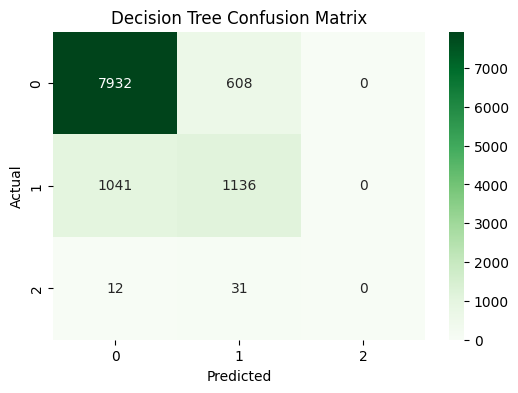

In [74]:
y_pred_tree = tree_model.predict(X_test)
cm_tree = confusion_matrix(y_test, y_pred_tree)
print("Decision Tree Confusion Matrix:\n", cm_tree)

plt.figure(figsize=(6,4))
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Greens")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 5.3 Evaluation of Random Forest

Random Forest Confusion Matrix:
 [[7851  687    2]
 [1195  981    1]
 [  18   25    0]]


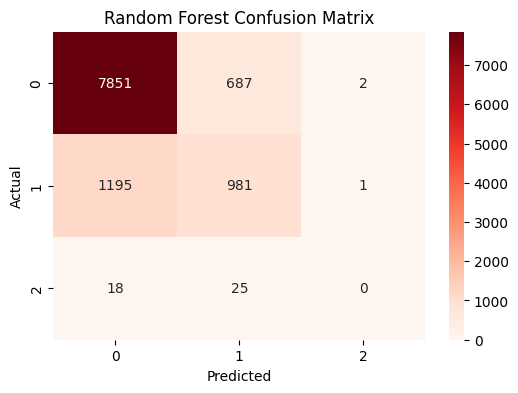

In [75]:
y_pred_rf = rf_model.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Random Forest Confusion Matrix:\n", cm_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Reds")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [82]:
print("---"*10,"LOGISTIC REGRESSION", "---"*10,"\n", classification_report(y_test, y_pred_log))
print("---"*10,"DECISION TREE", "---"*10,"\n", classification_report(y_test, y_pred_tree))
print("---"*10,"RANDOM FOREST", "---"*10,"\n", classification_report(y_test, y_pred_rf))

------------------------------ LOGISTIC REGRESSION ------------------------------ 
               precision    recall  f1-score   support

           1       0.79      1.00      0.88      8540
           2       0.00      0.00      0.00      2177
           3       0.00      0.00      0.00        43

    accuracy                           0.79     10760
   macro avg       0.26      0.33      0.29     10760
weighted avg       0.63      0.79      0.70     10760

------------------------------ DECISION TREE ------------------------------ 
               precision    recall  f1-score   support

           1       0.88      0.93      0.91      8540
           2       0.64      0.52      0.57      2177
           3       0.00      0.00      0.00        43

    accuracy                           0.84     10760
   macro avg       0.51      0.48      0.49     10760
weighted avg       0.83      0.84      0.83     10760

------------------------------ RANDOM FOREST ------------------------------ 

c:\Users\onnik\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\onnik\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\onnik\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

___ 
## 6. Deployment
